In [3]:
%cd ..

/scratch/big/home/daawic/BSc-Thesis


In [4]:
import os
import torch
import matplotlib.pyplot as plt
from torchvision.transforms import transforms
from project.models import EDMMauMau, EDMSerie
from project.util.data import ReplayMemoryData
from project.util.metrics import PSNR, MSE

In [ ]:
PATH = os.path.join("..", "checkpoints", "diff", "Breakout.pt")
DATA = os.path.join("..", "checkpoints", "memory", "Breakout.pt")
N = 8
SIGMA_NOISE_START = 0.1
SIGMA_NOISE_END = 1
NOISE_LEVELS = 4
SAMPLES = 1

In [17]:
device = "cuda:6"

In [18]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Pad(2),
    transforms.Normalize(0.5, 0.5),
])

In [ ]:
data = ReplayMemoryData(
    memory=DATA,
    transform=transform,
    cap=500_000,
    train=False,
)

In [13]:
psnrs_naive = torch.zeros((NOISE_LEVELS, SAMPLES))
psnrs_full= torch.zeros_like(psnrs_naive)

mses_naive = torch.zeros_like(psnrs_naive)
mses_full = torch.zeros_like(psnrs_naive)

noisy = torch.zeros((NOISE_LEVELS, SAMPLES, 4, 88, 88))
denoised_naive = torch.zeros((NOISE_LEVELS, SAMPLES, 4, 88, 88))
denoised_full = torch.zeros((NOISE_LEVELS, SAMPLES, 4, 88, 88))

x = torch.zeros((SAMPLES, 4, 88, 88), device=device)

for i, img in enumerate(torch.randperm(500_000)[:SAMPLES]):
    x[i] = data[img].to(device)

sigmas = torch.linspace(SIGMA_NOISE_START, SIGMA_NOISE_END, NOISE_LEVELS)

model_full = EDMSerie.from_checkpoint(PATH, device, sigma_noise=SIGMA_NOISE_START, N=N).to(device)
model_naive = EDMMauMau.from_checkpoint(PATH, device, sigma_noise=SIGMA_NOISE_START).to(device)

for i, sigma in enumerate(sigmas):

    model_full.set_sigma_noise(sigma)
    model_naive.set_sigma_noise(sigma)

    e = sigma * torch.randn_like(x)
    x_noisy = x + e
    noisy[i] = x_noisy

    with torch.no_grad():

        x_denoised_full = model_full.denoise(x_noisy)
        x_denoised_naive = model_naive.denoise(x_noisy)

        denoised_naive[i] = x_denoised_naive
        denoised_full[i] = x_denoised_full

        for j in range(SAMPLES):

            psnrs_full[i, j] = PSNR(x[j].to("cpu"), x_denoised_full[j].to("cpu"), torch.tensor(2).to("cpu"))
            psnrs_naive[i, j] = PSNR(x[j].to("cpu"), x_denoised_naive[j].to("cpu"), torch.tensor(2).to("cpu"))

            mses_full[i, j] = MSE(x[j].to("cpu"), x_denoised_full[j].to("cpu"))
            mses_naive[i, j] = MSE(x[j].to("cpu"), x_denoised_naive[j].to("cpu"))

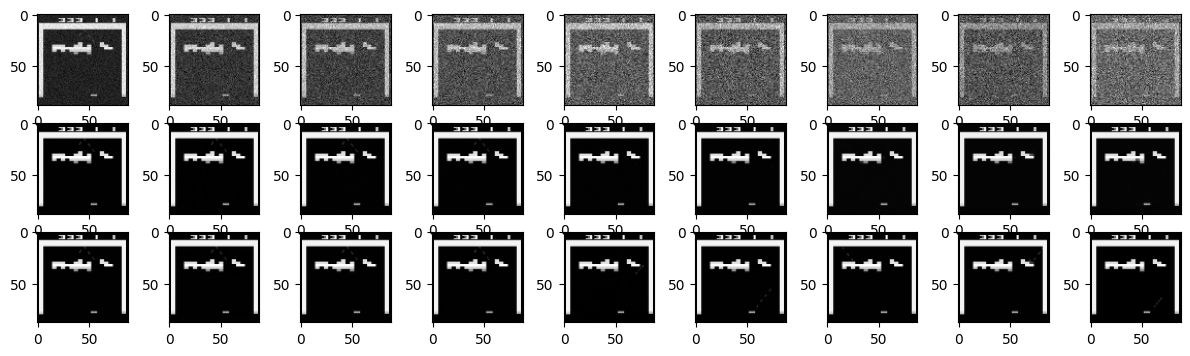

In [15]:
fig, axis = plt.subplots(3, NOISE_LEVELS, figsize=(15, 4))

for i, sigma_noise in enumerate(sigmas):

    axis[0, i].imshow(noisy[i, 0].to("cpu").mean(dim=0), cmap='grey')
    axis[1, i].imshow(denoised_naive[i, 0].to("cpu").mean(dim=0), cmap='grey')
    axis[2, i].imshow(denoised_full[i, 0].to("cpu").mean(dim=0), cmap='grey')